**Note:** use T4 GPU runtime on colab

#### **Clone git repo and install requirements**

In [1]:
import os

#check if the repository folder already exists on the Colab disk
if os.path.exists('/content/QML4EO-reproduction'):
    print("Repository found! Pulling latest changes from GitHub...")
    %cd /content/QML4EO-reproduction
    !git pull
else:
    print("Cloning repository for the first time...")
    %cd /content
    !git clone https://github.com/yeshapan/QML4EO-reproduction.git
    %cd QML4EO-reproduction

#install required dependencies
!pip install -r requirements.txt -q

Cloning repository for the first time...
/content
Cloning into 'QML4EO-reproduction'...
remote: Enumerating objects: 18, done.
remote: Counting objects: 100% (18/18), done.
remote: Compressing objects: 100% (14/14), done.
remote: Total 18 (delta 3), reused 16 (delta 1), pack-reused 0 (from 0)
Receiving objects: 100% (18/18), 6.68 MiB | 27.70 MiB/s, done.
Resolving deltas: 100% (3/3), done.
/content/QML4EO-reproduction
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 62.0/62.0 kB 5.0 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 57.2/57.2 kB 5.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.3/5.3 MB 44.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 935.6/935.6 kB 53.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.8/6.8 MB 45.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 231.9/231.9 kB 25.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.5/2.5 MB 82.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━

#### **Test data loader (and confirm satellite images are loading correctly)**

Downloading/Loading EuroSAT dataset into ./data...


100%|██████████| 94.3M/94.3M [00:01<00:00, 78.4MB/s]


Dataset loaded successfully!
Total images: 27000 | Training: 21600 | Validation: 5400
Classes: ['AnnualCrop', 'Forest', 'HerbaceousVegetation', 'Highway', 'Industrial', 'Pasture', 'PermanentCrop', 'Residential', 'River', 'SeaLake']

Batch Image Tensor Shape: torch.Size([32, 3, 64, 64])
Batch Label Tensor Shape: torch.Size([32])


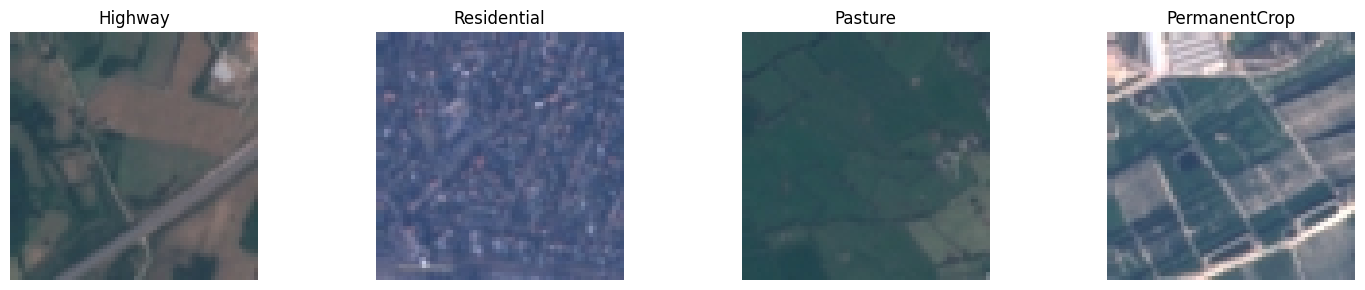

In [2]:
import matplotlib.pyplot as plt
import numpy as np

#import your custom data loader from the src/utils folder
from src.utils.data_loader import get_eurosat_dataloaders

#download and load the data
train_loader, val_loader, classes = get_eurosat_dataloaders(
    data_dir="./data",
    batch_size=32,
    img_size=64
)

#grab exactly one batch of data to inspect it
images, labels = next(iter(train_loader))
print(f"\nBatch Image Tensor Shape: {images.shape}")
print(f"Batch Label Tensor Shape: {labels.shape}")

#let's visualize the first 4 images to make sure they look right
fig, axes = plt.subplots(1, 4, figsize=(15, 3))

#we have to reverse the mathematical normalization we did in data_loader.py so matplotlib can display the actual RGB colors correctly
mean = np.array([0.485, 0.456, 0.406])
std = np.array([0.229, 0.224, 0.225])

for i in range(4):
    #PyTorch uses (Channels, Height, Width), but Matplotlib needs (Height, Width, Channels)
    img = images[i].numpy().transpose((1, 2, 0))
    img = std * img + mean #un-normalize
    img = np.clip(img, 0, 1) #lock pixel values between 0 and 1

    axes[i].imshow(img)
    axes[i].set_title(classes[labels[i]])
    axes[i].axis('off')

plt.tight_layout()
plt.show()

#### **Training the Classical Baseline (CNN)**

Now, we'll establish our classical benchmark. We initialize the lightweight PyTorch CNN (resolution-agnostic via Adaptive Average Pooling) and train it on the EuroSAT dataset.

The goal here is to record the **Total Trainable Parameters**, **Training Time**, and **Validation Accuracy** to serve as a direct point of comparison for our hybrid quantum-classical models later.

In [3]:
import torch
from src.utils.data_loader import get_eurosat_dataloaders
from src.baselines.cnn import ClassicalCNN, train_baseline

#verify device and connect to the T4 GPU
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Hardware utilized: {device}")

#re-initialize the dataloaders for a clean training run
train_loader, val_loader, classes = get_eurosat_dataloaders(
    data_dir="./data",
    batch_size=32,
    img_size=64
)

#initialize the classical CNN baseline
model = ClassicalCNN(num_classes=len(classes))
model = model.to(device) #push the model to the GPU

#calculate and print total trainable parameters
total_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"Total Trainable Parameters (Classical CNN): {total_params:,}")

#execute the training loop!
#we'll run for 5 epochs to establish a solid baseline without taking too much time
print("\n--- Starting Classical Training ---")
history = train_baseline(
    model=model,
    train_loader=train_loader,
    val_loader=val_loader,
    epochs=5,
    lr=0.001,
    device=device
)

print("\nBaseline training complete!")

Hardware utilized: cuda
Downloading/Loading EuroSAT dataset into ./data...
Dataset loaded successfully!
Total images: 27000 | Training: 21600 | Validation: 5400
Classes: ['AnnualCrop', 'Forest', 'HerbaceousVegetation', 'Highway', 'Industrial', 'Pasture', 'PermanentCrop', 'Residential', 'River', 'SeaLake']
Total Trainable Parameters (Classical CNN): 5,418

--- Starting Classical Training ---


Epoch 1/5 [Train]: 100%|██████████| 675/675 [00:14<00:00, 46.14it/s, loss=0.9658]


Epoch 1 Summary -> Train Loss: 1.5620 | Val Accuracy: 55.06%


Epoch 2/5 [Train]: 100%|██████████| 675/675 [00:13<00:00, 49.82it/s, loss=0.8901]


Epoch 2 Summary -> Train Loss: 1.0952 | Val Accuracy: 66.30%


...

Epoch 3 Summary -> Train Loss: 0.9006 | Val Accuracy: 70.35%


Epoch 4/5 [Train]: 100%|██████████| 675/675 [00:14<00:00, 47.91it/s, loss=0.7908]


Epoch 4 Summary -> Train Loss: 0.8016 | Val Accuracy: 73.50%


Epoch 5/5 [Train]: 100%|██████████| 675/675 [00:14<00:00, 47.45it/s, loss=0.7680]


Epoch 5 Summary -> Train Loss: 0.7445 | Val Accuracy: 74.31%

Baseline training complete!
